----------------------------------------------------------------------------------------------------

<h1><center>Federal Reserve Education</h1></center>


<p><center>This notebook is for the analysis and evaluation of the Federal Reserve Bank of Saint Louis in join collaboration with NZ Economic Data for future projections, policy briefs, data visualisations, and indexing.</center></p>



----------------------------------------------------------------------------------------------------

<h2><center>Preliminary Economic Evaluations (Macroeconomic Understandings)</h2></center>

<p><center>Below we will analyse current trends in unemployment, gdp, and consumer purchasing index by first using the U.S. Federal Reserve Bank of Saint Louis, publicly available economic (macro) datasets. We will understand how to make use of Python Pandas DataFrames, functions, and proper data indexing for ease of data visulisations using matplotlib. As the notebook evolves, we will make use of seaborn mechanics and functions for greater quality of graphing.</p></center>

----------------------------------------------------------------------------------------------------

**Data Note**

CSV files were downloaded manually from the Federal Reserve Economic Data (FRED) database.
File paths are assumed to be relative to the repository structure and may need adjustment
depending on local setup.


----------------------------------------------------------------------------------------------------

<h1><center>Data Preparation</h2></center>

<p><center>Below is the code segments designed for preparing the data for analysis. </p></center>

----------------------------------------------------------------------------------------------------

In [114]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("..") / "data"

def load_fred_csv(filename: str) -> pd.DataFrame:
    """Load a FRED CSV from the repo /data folder."""
    return pd.read_csv(DATA_DIR / filename)

def prep_time_series(df: pd.DataFrame, date_col: str = "observation_date") -> pd.DataFrame:
    """Parse dates, drop missing dates, sort by time."""
    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col], errors="coerce")
    out = out.dropna(subset=[date_col]).sort_values(date_col)
    return out

def annualize_monthly(
    df: pd.DataFrame,
    value_col: str,
    date_col: str = "observation_date",
    how: str = "mean",   # "mean" (default) or "last"
) -> pd.DataFrame:
    """
    Convert a monthly time series into annual values.
    - how="mean": annual average of monthly values
    - how="last": end-of-year value (last month available)
    Returns columns: year, <value_col>
    """
    out = prep_time_series(df, date_col=date_col)
    out[value_col] = pd.to_numeric(out[value_col], errors="coerce")
    out = out.dropna(subset=[value_col])

    out["year"] = out[date_col].dt.year

    if how == "mean":
        annual = out.groupby("year", as_index=False)[value_col].mean()
    elif how == "last":
        annual = out.sort_values(date_col).groupby("year", as_index=False).tail(1)[["year", value_col]]
    else:
        raise ValueError("how must be 'mean' or 'last'")

    return annual


In [115]:
cpi = load_fred_csv("CPIAUCSL_PC1.csv")
unemployment = load_fred_csv("UNRATE.csv")

annual_cpi = annualize_monthly(cpi, value_col="CPIAUCSL_PC1", how="mean")
annual_unrate = annualize_monthly(unemployment, value_col="UNRATE", how="mean")


In [116]:
# df['date'].dt.year
# df['Date'] = pd.to_datetime(df['Date'])
# df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y') 
# Example format codes: %Y for year, %m for month, %d for day, etc. 
# See the [Python documentation](docs.python.org) for all options
cpi['observation_date'] = pd.to_datetime(cpi['observation_date'])
cpi['year'] = cpi['observation_date'].dt.year
cpi.head(23)


,observation_date,CPIAUCSL_PC1,year
0,1948-01-01,10.24209,1948
1,1948-02-01,9.48196,1948
2,1948-03-01,6.81818,1948
3,1948-04-01,8.27273,1948
4,1948-05-01,9.38497,1948
5,1948-06-01,9.37500,1948
6,1948-07-01,9.76158,1948
7,1948-08-01,9.06250,1948
8,1948-09-01,6.65499,1948
9,1948-10-01,6.11087,1948


<h3><center>Data Visualisation for CPI (Consumer Purchasing Index)</h3></center>


----------------------------------------------------------------------------------------------------

In [117]:
annual_cpi = (
    cpi
    .sort_values('observation_date')
    .groupby('year', as_index=False)
    .tail(1)
)



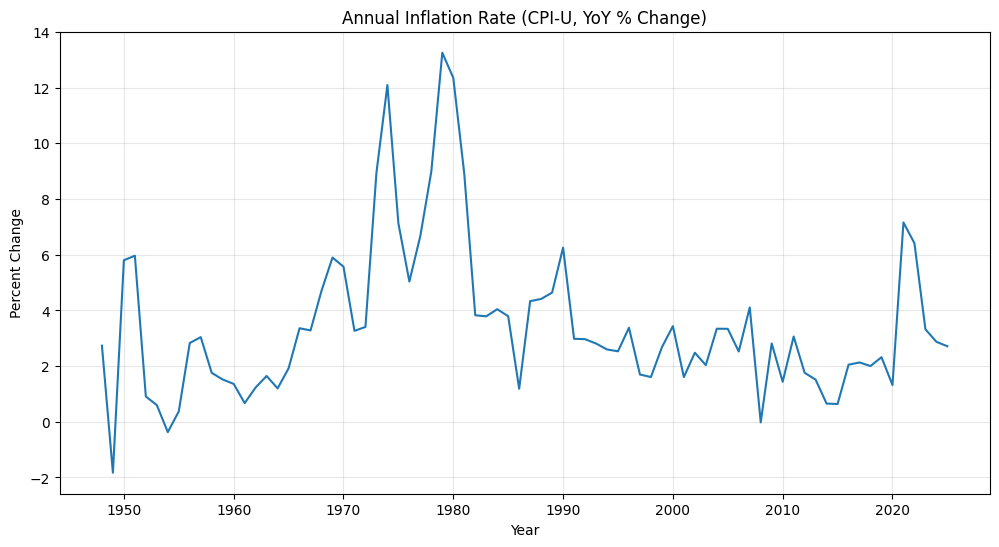

In [118]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(annual_cpi["year"], annual_cpi["CPIAUCSL_PC1"])
ax.set_title("Annual Inflation Rate (CPI-U, YoY % Change)")
ax.set_xlabel("Year")
ax.set_ylabel("Percent Change")
ax.grid(True, alpha=0.3)
plt.show()


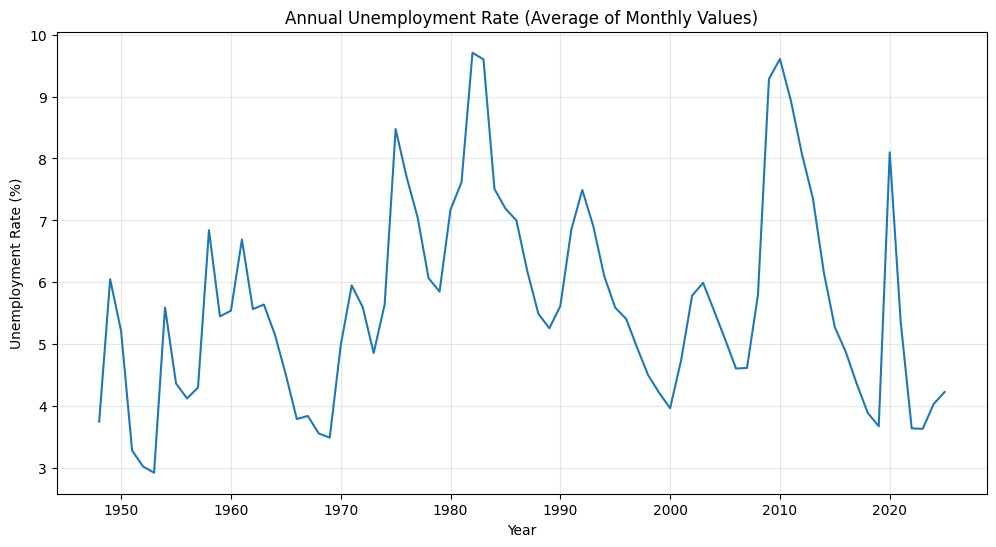

In [119]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(annual_unrate["year"], annual_unrate["UNRATE"])
ax.set_title("Annual Unemployment Rate (Average of Monthly Values)")
ax.set_xlabel("Year")
ax.set_ylabel("Unemployment Rate (%)")
ax.grid(True, alpha=0.3)
plt.show()


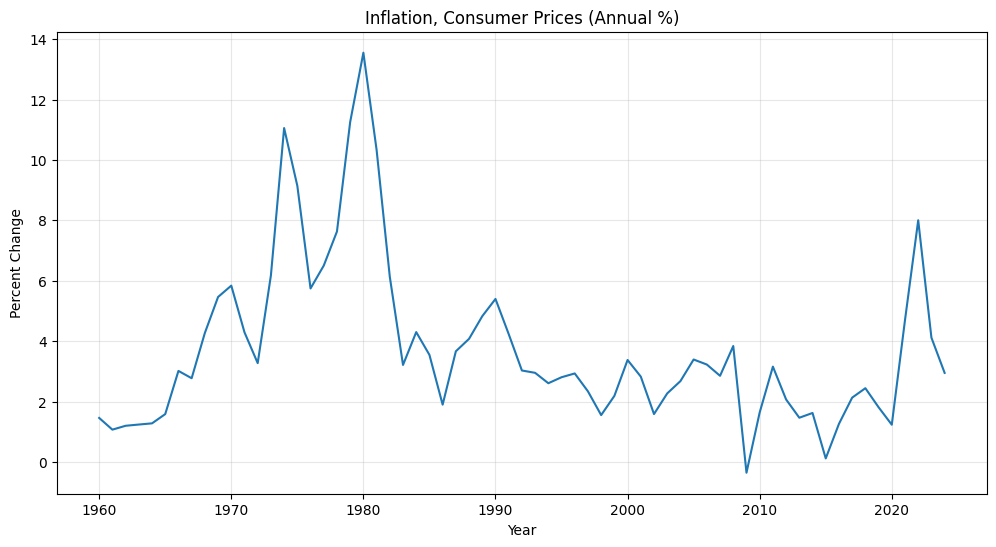

In [120]:
infl_annual = load_fred_csv("FPCPITOTLZGUSA.csv")
infl_annual = prep_time_series(infl_annual)

# If the column name differs, replace "FPCPITOTLZGUSA" accordingly
infl_annual["year"] = infl_annual["observation_date"].dt.year
infl_annual["FPCPITOTLZGUSA"] = pd.to_numeric(infl_annual["FPCPITOTLZGUSA"], errors="coerce")
infl_annual = infl_annual.dropna(subset=["FPCPITOTLZGUSA"])

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(infl_annual["year"], infl_annual["FPCPITOTLZGUSA"])
ax.set_title("Inflation, Consumer Prices (Annual %)")
ax.set_xlabel("Year")
ax.set_ylabel("Percent Change")
ax.grid(True, alpha=0.3)
plt.show()
